In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [2]:
df = pd.read_excel("/content/customer.xlsx")

In [3]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
LE = LabelEncoder()
df['InvoiceNo'] = LE.fit_transform(df['InvoiceNo'].astype(str))
df['StockCode'] = LE.fit_transform(df['StockCode'].astype(str))
df['Description'] = LE.fit_transform(df['Description'].astype(str))
df['InvoiceDate'] = LE.fit_transform(df['InvoiceDate'].astype(str))
df['Country'] = LE.fit_transform(df['Country'].astype(str))

In [7]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,3536,3918,6,0,2.55,17850.0,36
1,0,2794,3926,6,0,3.39,17850.0,36
2,0,3044,913,8,0,2.75,17850.0,36
3,0,2985,1910,6,0,3.39,17850.0,36
4,0,2984,2911,6,0,3.39,17850.0,36


In [9]:
SS = StandardScaler()
df['StockCode'] = SS.fit_transform(df[['StockCode']])
df['Description'] = SS.fit_transform(df[['Description']])
df['CustomerID'] = SS.fit_transform(df[['CustomerID']])

In [10]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,2.021115,1.551123,6,0,2.55,1.49528,36
1,0,1.225665,1.558087,6,0,3.39,1.49528,36
2,0,1.493674,-1.064697,8,0,2.75,1.49528,36
3,0,1.430424,-0.196819,6,0,3.39,1.49528,36
4,0,1.429352,0.674541,6,0,3.39,1.49528,36


In [11]:
df.describe()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.000000,5.419090e+05,5.419090e+05,541909.000000,541909.000000,541909.000000,4.068290e+05,541909.000000
mean,11648.523427,-8.758713e-17,1.795930e-16,9.552250,12164.309502,4.611114,-3.085785e-16,34.259772
std,6730.300232,1.000001e+00,1.000001e+00,218.081158,6971.111557,96.759853,1.000001e+00,6.222861
min,0.000000,-1.769601e+00,-1.859454e+00,-80995.000000,0.000000,-11062.060000,-1.716675e+00,0.000000
25%,5553.000000,-7.340150e-01,-8.070321e-01,1.000000,5895.000000,1.250000,-7.788819e-01,36.000000
50%,11967.000000,-9.401008e-02,-3.055573e-02,3.000000,12565.000000,2.080000,-7.918459e-02,36.000000
75%,17484.000000,5.610033e-01,8.643072e-01,10.000000,18344.000000,4.130000,8.772823e-01,36.000000
max,25899.000000,2.592510e+00,1.816622e+00,80995.000000,23259.000000,38970.000000,1.750299e+00,37.000000


In [12]:
df.shape

(541909, 8)

In [13]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [14]:
df['CustomerID'] = df['CustomerID'].fillna(df['CustomerID'].mean())

In [15]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [16]:
X_question = df.drop(columns='CustomerID',axis=1)
q_mean = X_question.mean(axis=0)
total_mean = q_mean.mean()

In [17]:
X_question.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Country
0,0,2.021115,1.551123,6,0,2.55,36
1,0,1.225665,1.558087,6,0,3.39,36
2,0,1.493674,-1.064697,8,0,2.75,36
3,0,1.430424,-0.196819,6,0,3.39,36
4,0,1.429352,0.674541,6,0,3.39,36


In [18]:
q_mean

,0
InvoiceNo,1.164852e+04
StockCode,-8.758713e-17
Description,1.795930e-16
Quantity,9.552250e+00
InvoiceDate,1.216431e+04
UnitPrice,4.611114e+00
Country,3.425977e+01


In [19]:
total_mean

np.float64(3408.750866440675)

In [20]:
q_mean = q_mean.to_frame('mean')
q_mean.reset_index(level=0,inplace=True)

In [21]:
q_mean

,index,mean
0,InvoiceNo,1.164852e+04
1,StockCode,-8.758713e-17
2,Description,1.795930e-16
3,Quantity,9.552250e+00
4,InvoiceDate,1.216431e+04
5,UnitPrice,4.611114e+00
6,Country,3.425977e+01


<Axes: xlabel='index', ylabel='mean'>

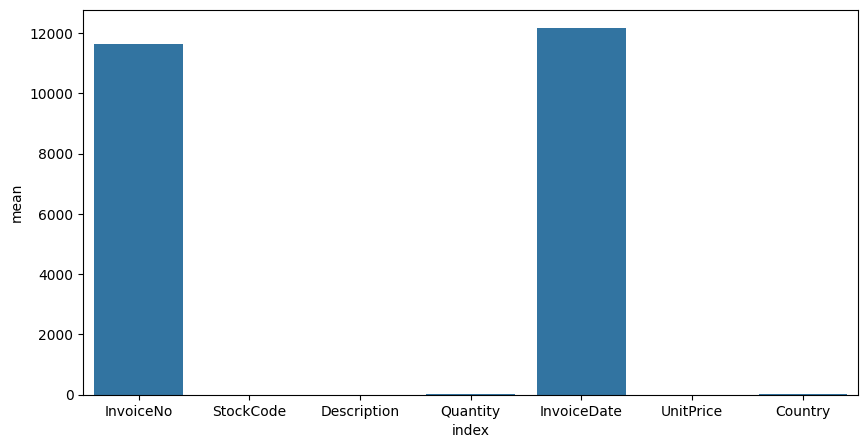

In [23]:
plt.figure(figsize=(10,5))
sns.barplot(x='index',y='mean',data=q_mean)

<Axes: >

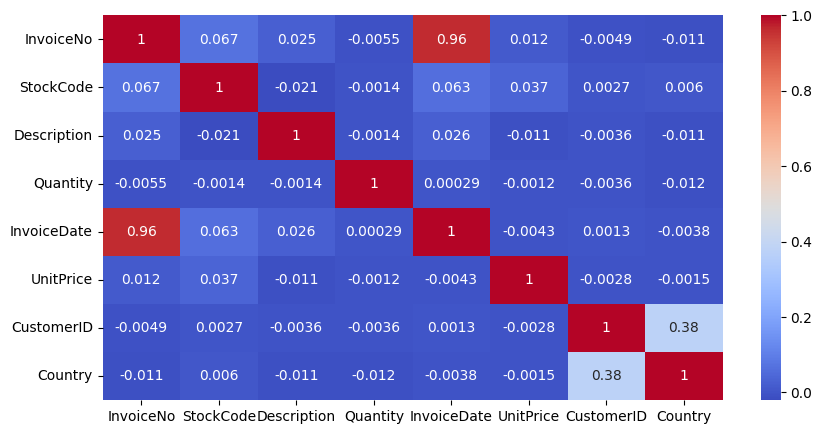

In [25]:
corr = df.corr()
plt.figure(figsize=(10,5))
sns.heatmap(corr,annot=True,cmap='coolwarm')

In [26]:
X = df.drop(columns='CustomerID',axis=1)
pca = PCA(n_components=2,random_state=42)
X_pca = pca.fit_transform(X)

In [27]:
pca

PCA(n_components=2, random_state=42)

In [28]:
X_pca

array([[-16842.06815528,     57.08645589],
       [-16842.06813064,     57.09004981],
       [-16842.06827421,     57.08023737],
       ...,
       [ 15213.44434533,   -205.22344244],
       [ 15213.44434534,   -205.22344242],
       [ 15213.44442293,   -205.21648303]])

In [29]:
pca.explained_variance_ratio_.cumsum()[0]

np.float64(0.9804235658237216)

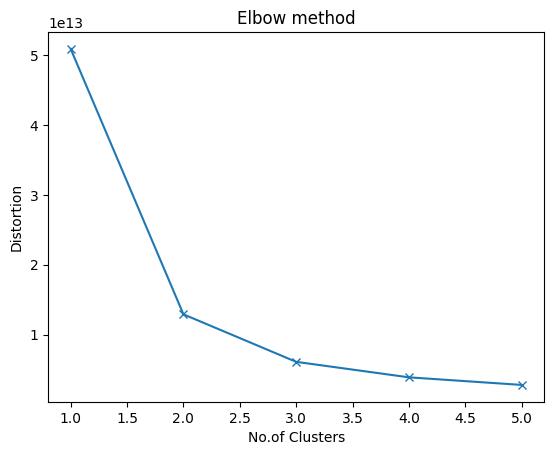

In [30]:
distortion = []
for i in range(1,6):
  km = KMeans(n_clusters=i,init='k-means++',random_state=42,n_init=10)
  km.fit(X_pca)
  distortion.append(km.inertia_)
plt.plot(range(1,6),distortion,marker='x')
plt.xlabel("No.of Clusters")
plt.ylabel("Distortion")
plt.title("Elbow method")
plt.show()

In [31]:
model = KMeans(n_clusters = 3,init='k-means++',random_state=42,n_init=10)
model.fit(X_pca)
y = model.predict(X_pca)

In [32]:
model

KMeans(n_clusters=3, n_init=10, random_state=42)

In [33]:
y

array([1, 1, 1, ..., 0, 0, 0], dtype=int32)

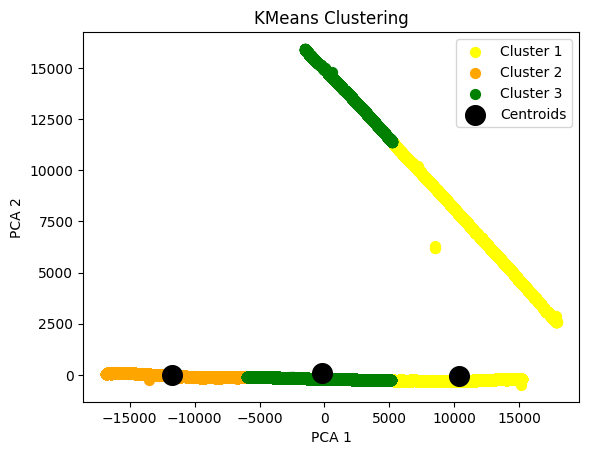

In [34]:
plt.scatter(X_pca[y==0,0],X_pca[y==0,1],s=50,c='yellow',label="Cluster 1")
plt.scatter(X_pca[y==1,0],X_pca[y==1,1],s=50,c='orange',label="Cluster 2")
plt.scatter(X_pca[y==2,0],X_pca[y==2,1],s=50,c='green',label="Cluster 3")
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],s=200,c='black',label="Centroids")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("KMeans Clustering")
plt.legend()
plt.show()